In [1]:
# ============================================
# Portfolio Optimization - Efficient Frontier
# ============================================

# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Pour que les graphes s'affichent dans le notebook
%matplotlib inline

# Reproductibilité
np.random.seed(42)


# 2. Parameters
tickers = ["SPY", "QQQ", "GLD", "AGG", "EFA"]
start_date = "2020-01-01"
end_date = "2026-03-13"
risk_free_rate = 0.02   # 2% annual
num_portfolios = 10000


# 3. Download adjusted close prices
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]

# Drop missing values
data = data.dropna()

print("Price data shape:", data.shape)
data.head()

[*********************100%***********************]  5 of 5 completed


Price data shape: (1556, 5)


Ticker,AGG,EFA,GLD,QQQ,SPY
Date,,,,,
2020-01-02,94.454140,58.637081,143.949997,208.580215,297.698975
2020-01-03,94.730766,57.909767,145.860001,206.669662,295.444702
2020-01-06,94.655319,58.135490,147.389999,208.001266,296.571869
2020-01-07,94.554718,57.976646,147.970001,207.972336,295.737976
2020-01-08,94.445755,58.143845,146.860001,209.535477,297.314148


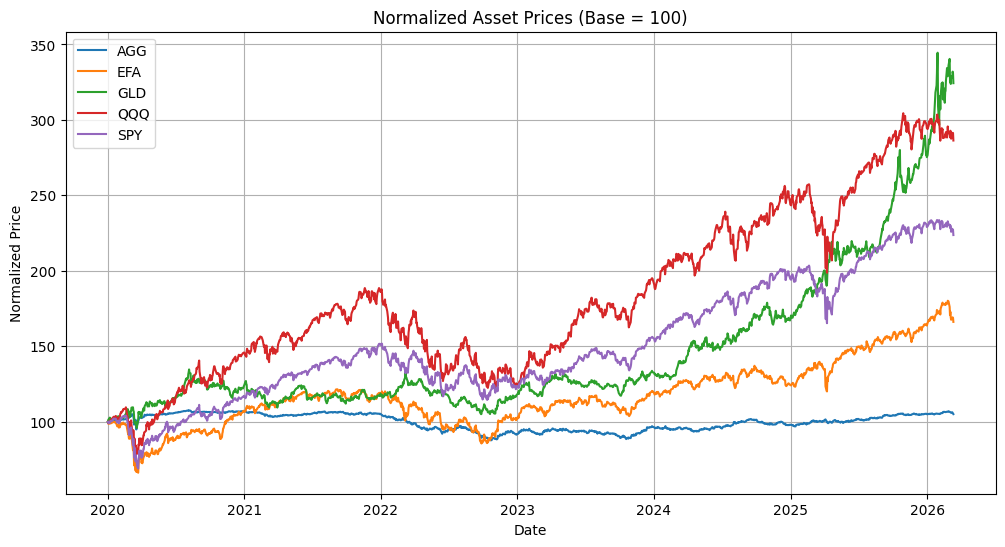

In [2]:
# 4. Plot normalized prices
normalized_prices = data / data.iloc[0] * 100

plt.figure(figsize=(12, 6))
for col in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[col], label=col)

plt.title("Normalized Asset Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# 5. Compute daily returns
daily_returns = data.pct_change().dropna()
daily_returns.head()

Ticker,AGG,EFA,GLD,QQQ,SPY
Date,,,,,
2020-01-03,0.002929,-0.012404,0.013269,-0.009160,-0.007572
2020-01-06,-0.000796,0.003898,0.010490,0.006443,0.003815
2020-01-07,-0.001063,-0.002732,0.003935,-0.000139,-0.002812
2020-01-08,-0.001152,0.002884,-0.007502,0.007516,0.005330
2020-01-09,0.001065,0.002301,-0.005652,0.008474,0.006781


In [4]:
# 6. Annualized mean returns and covariance matrix
trading_days = 252

annual_returns = daily_returns.mean() * trading_days
annual_cov = daily_returns.cov() * trading_days

print("Annual Returns:")
print(annual_returns)
print("\nAnnual Covariance Matrix:")
print(annual_cov)

Annual Returns:
Ticker
AGG    0.010165
EFA    0.101089
GLD    0.206397
QQQ    0.202040
SPY    0.151672
dtype: float64

Annual Covariance Matrix:
Ticker       AGG       EFA       GLD       QQQ       SPY
Ticker                                                  
AGG     0.004139  0.002894  0.003236  0.002710  0.002300
EFA     0.002894  0.037248  0.008200  0.036590  0.033837
GLD     0.003236  0.008200  0.031156  0.006087  0.004555
QQQ     0.002710  0.036590  0.006087  0.062909  0.048234
SPY     0.002300  0.033837  0.004555  0.048234  0.042169


In [5]:
# 7. Portfolio performance function
def portfolio_performance(weights, mean_returns, cov_matrix):
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility


def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_return, p_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_return - risk_free_rate) / p_vol

In [6]:
# 8. Simulate random portfolios
results = np.zeros((4, num_portfolios))
weights_record = []

num_assets = len(tickers)

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return, portfolio_volatility = portfolio_performance(weights, annual_returns, annual_cov)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe_ratio
    results[3, i] = i

results_df = pd.DataFrame(results.T, columns=["Return", "Volatility", "Sharpe", "Portfolio_Index"])
results_df.head()

,Return,Volatility,Sharpe,Portfolio_Index
0,0.140691,0.141502,0.852925,0.0
1,0.173713,0.150061,1.024338,1.0
2,0.153601,0.148660,0.898705,2.0
3,0.156933,0.145328,0.942234,3.0
4,0.119947,0.124130,0.805182,4.0


In [7]:
# 9. Identify the best portfolios
max_sharpe_idx = results_df["Sharpe"].idxmax()
min_vol_idx = results_df["Volatility"].idxmin()

max_sharpe_portfolio = results_df.loc[max_sharpe_idx]
min_vol_portfolio = results_df.loc[min_vol_idx]

max_sharpe_weights = weights_record[int(max_sharpe_portfolio["Portfolio_Index"])]
min_vol_weights = weights_record[int(min_vol_portfolio["Portfolio_Index"])]

print("Maximum Sharpe Ratio Portfolio")
print(max_sharpe_portfolio)
print("\nWeights:")
print(pd.Series(max_sharpe_weights, index=tickers))

print("\n" + "="*50 + "\n")

print("Minimum Volatility Portfolio")
print(min_vol_portfolio)
print("\nWeights:")
print(pd.Series(min_vol_weights, index=tickers))

Maximum Sharpe Ratio Portfolio
Return                0.199410
Volatility            0.151042
Sharpe                1.187819
Portfolio_Index    2592.000000
Name: 2592, dtype: float64

Weights:
SPY    0.003143
QQQ    0.024775
GLD    0.738733
AGG    0.178857
EFA    0.054491
dtype: float64


Minimum Volatility Portfolio
Return                0.062541
Volatility            0.072970
Sharpe                0.582994
Portfolio_Index    5852.000000
Name: 5852, dtype: float64

Weights:
SPY    0.680698
QQQ    0.079007
GLD    0.187086
AGG    0.018866
EFA    0.034343
dtype: float64


In [8]:
# 10. Convert optimal weights to clean tables
max_sharpe_weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": max_sharpe_weights
}).sort_values(by="Weight", ascending=False)

min_vol_weights_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": min_vol_weights
}).sort_values(by="Weight", ascending=False)

print("Max Sharpe Weights")
display(max_sharpe_weights_df)

print("Min Vol Weights")
display(min_vol_weights_df)

Max Sharpe Weights


,Asset,Weight
2,GLD,0.738733
3,AGG,0.178857
4,EFA,0.054491
1,QQQ,0.024775
0,SPY,0.003143


Min Vol Weights


,Asset,Weight
0,SPY,0.680698
2,GLD,0.187086
1,QQQ,0.079007
4,EFA,0.034343
3,AGG,0.018866


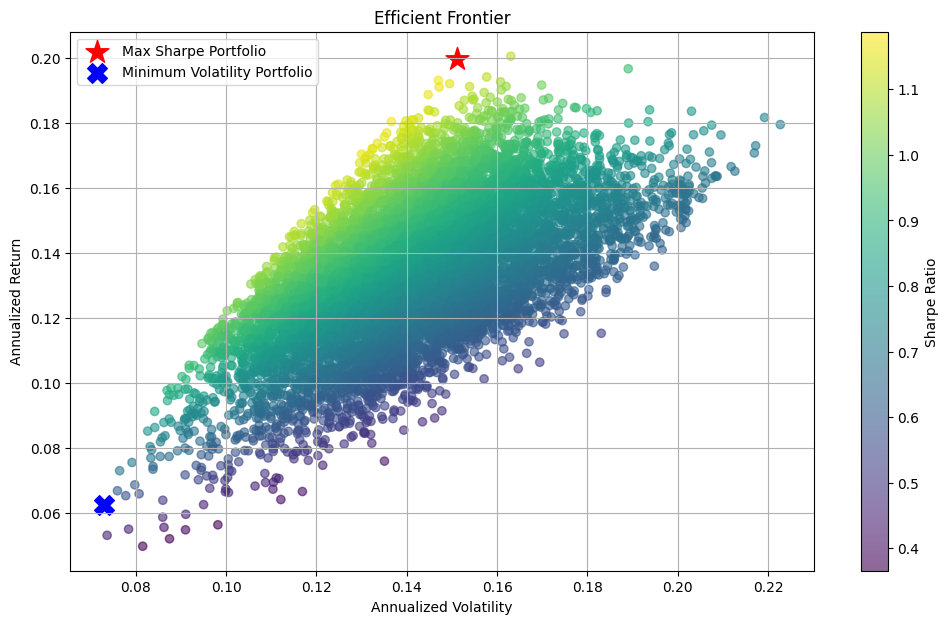

In [9]:
# 11. Plot Efficient Frontier
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

# Highlight max Sharpe portfolio
plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Return"],
    color="red",
    marker="*",
    s=300,
    label="Max Sharpe Portfolio"
)

# Highlight minimum volatility portfolio
plt.scatter(
    min_vol_portfolio["Volatility"],
    min_vol_portfolio["Return"],
    color="blue",
    marker="X",
    s=200,
    label="Minimum Volatility Portfolio"
)

plt.title("Efficient Frontier")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.grid(True)
plt.show()

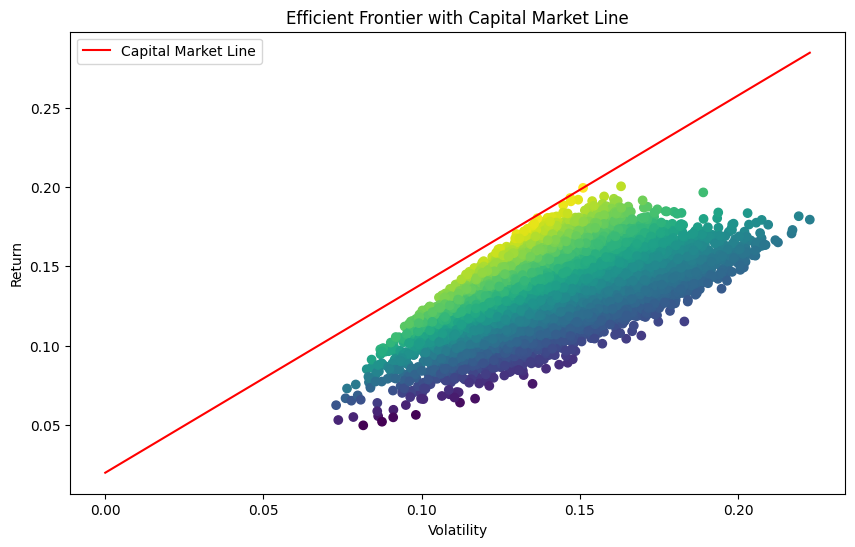

In [15]:
# Capital Market Line

rf = 0.02

max_sharpe_return = max_sharpe_portfolio["Return"]
max_sharpe_vol = max_sharpe_portfolio["Volatility"]

cml_x = np.linspace(0, results_df["Volatility"].max(), 100)
cml_y = rf + (max_sharpe_return - rf) / max_sharpe_vol * cml_x

plt.figure(figsize=(10,6))

plt.scatter(results_df["Volatility"], results_df["Return"], c=results_df["Sharpe"], cmap="viridis")
plt.plot(cml_x, cml_y, color="red", label="Capital Market Line")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier with Capital Market Line")

plt.legend()
plt.show()

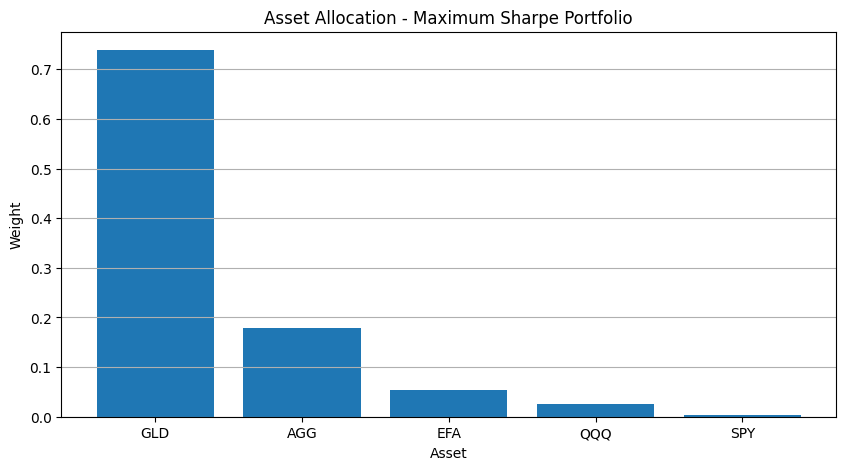

In [14]:
# 12. Bar chart of optimal weights - Max Sharpe
plt.figure(figsize=(10, 5))
plt.bar(max_sharpe_weights_df["Asset"], max_sharpe_weights_df["Weight"])
plt.title("Asset Allocation - Maximum Sharpe Portfolio")
plt.xlabel("Asset")
plt.ylabel("Weight")
plt.grid(axis="y")
plt.show()

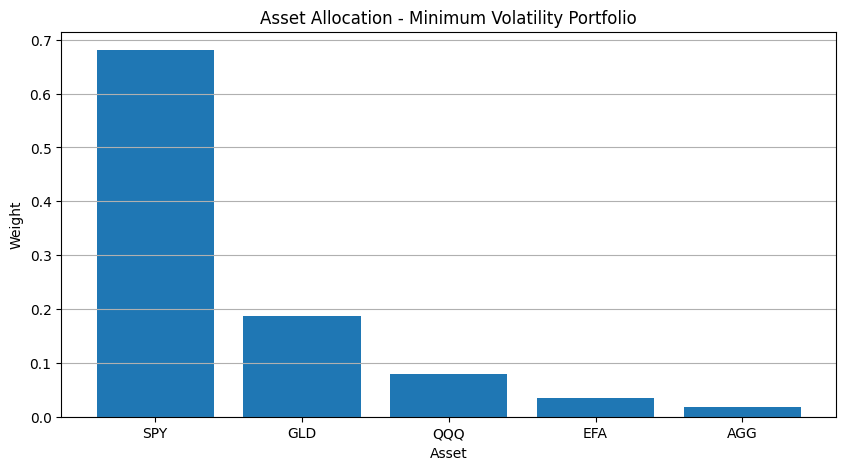

In [11]:
# 13. Bar chart of optimal weights - Minimum Volatility
plt.figure(figsize=(10, 5))
plt.bar(min_vol_weights_df["Asset"], min_vol_weights_df["Weight"])
plt.title("Asset Allocation - Minimum Volatility Portfolio")
plt.xlabel("Asset")
plt.ylabel("Weight")
plt.grid(axis="y")
plt.show()

In [12]:
# 14. Final summary table
summary_df = pd.DataFrame({
    "Portfolio": ["Maximum Sharpe", "Minimum Volatility"],
    "Annual Return": [max_sharpe_portfolio["Return"], min_vol_portfolio["Return"]],
    "Annual Volatility": [max_sharpe_portfolio["Volatility"], min_vol_portfolio["Volatility"]],
    "Sharpe Ratio": [max_sharpe_portfolio["Sharpe"], min_vol_portfolio["Sharpe"]]
})

summary_df

,Portfolio,Annual Return,Annual Volatility,Sharpe Ratio
0,Maximum Sharpe,0.199410,0.151042,1.187819
1,Minimum Volatility,0.062541,0.072970,0.582994


In [13]:
# 15. Interpretation
print("Project Interpretation:")
print("- The Maximum Sharpe portfolio offers the best risk-adjusted return.")
print("- The Minimum Volatility portfolio focuses on reducing total portfolio risk.")
print("- The Efficient Frontier shows the trade-off between risk and expected return.")

Project Interpretation:
- The Maximum Sharpe portfolio offers the best risk-adjusted return.
- The Minimum Volatility portfolio focuses on reducing total portfolio risk.
- The Efficient Frontier shows the trade-off between risk and expected return.


## Conclusion

This project demonstrates how Modern Portfolio Theory can be used to construct an optimal ETF portfolio.

The efficient frontier illustrates the trade-off between expected return and portfolio risk.

The maximum Sharpe portfolio offers the best risk-adjusted performance, while the minimum volatility portfolio focuses on reducing overall risk.